In [1]:
import pickle as pkl
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os

def load_results_dict(dir, filename):
    with open(dir+'/'+filename, 'rb') as f:
        results = pkl.load(f)
    return results





def load_results_dict(filename):
    with open(filename, 'rb') as f:
        results = pkl.load(f)
    return results

multitask = True
date = '2024-10-22'
    
fixed_name = '_multi_task_exp_weighed_'
    
dir = 'heterogeneity_results'
suffix = '_4k'
filenames = {
    'ESN': {
        'net_wide': {
            'dd': "C:/Users/Nishant Joshi/DDN_dynamics/DDN-public/heterogeneity_results/2025-02-12_single_task_exp_BL_dist_decay_net_wide.p",
           'fd': "C:/Users/Nishant Joshi/DDN_dynamics/DDN-public/heterogeneity_results/2025-03-19_single_task_exp_BL_fixed_decay_net_wide.p"
       },
        'per_cluster': {
            'dd': "C:/Users/Nishant Joshi/DDN_dynamics/DDN-public/heterogeneity_results/2025-02-12_single_task_exp_BL_dist_decay_per_cluster.p",
           'fd': "C:/Users/Nishant Joshi/DDN_dynamics/DDN-public/heterogeneity_results/2025-02-12_single_task_exp_BL_fixed_decay_per_cluster.p"
       }
    },
    'DDN':{
        'net_wide': {
        'dd':'C:/Users/Nishant Joshi/DDN_dynamics/DDN-public/heterogeneity_results/2025-02-12_single_task_exp_DDN_dist_decay_net_wide.p',
        'fd':'C:/Users/Nishant Joshi/DDN_dynamics/DDN-public/heterogeneity_results/2025-02-12_single_task_exp_DDN_fixed_decay_net_wide.p',
        },
        'per_cluster': {    
        'dd':'C:/Users/Nishant Joshi/DDN_dynamics/DDN-public/heterogeneity_results/2025-04-24_single_task_exp_DDN_dist_decay_per_cluster.p',
        'fd':'C:/Users/Nishant Joshi/DDN_dynamics/DDN-public/heterogeneity_results/2025-02-13_single_task_exp_DDN_fixed_decay_per_cluster.p',
        }
    }
}
# Parameters
max_gen = 150

# Validation Scores
Import and plot validation performances and hyperparameters

In [3]:
results_dicts = {}
for factor_1 in filenames:
    results_dicts[factor_1] = {}
    for factor_2 in filenames[factor_1]:
        results_dicts[factor_1][factor_2] = {}
        for factor_3 in filenames[factor_1][factor_2]:
            print('loading: ' + filenames[factor_1][factor_2][factor_3])
            results_dicts[factor_1][factor_2][factor_3] = load_results_dict(filenames[factor_1][factor_2][factor_3])

loading: C:/Users/Nishant Joshi/DDN_dynamics/DDN-public/heterogeneity_results/2025-02-12_single_task_exp_BL_dist_decay_net_wide.p
loading: C:/Users/Nishant Joshi/DDN_dynamics/DDN-public/heterogeneity_results/2025-03-19_single_task_exp_BL_fixed_decay_net_wide.p
loading: C:/Users/Nishant Joshi/DDN_dynamics/DDN-public/heterogeneity_results/2025-02-12_single_task_exp_BL_dist_decay_per_cluster.p
loading: C:/Users/Nishant Joshi/DDN_dynamics/DDN-public/heterogeneity_results/2025-02-12_single_task_exp_BL_fixed_decay_per_cluster.p
loading: C:/Users/Nishant Joshi/DDN_dynamics/DDN-public/heterogeneity_results/2025-02-12_single_task_exp_DDN_dist_decay_net_wide.p
loading: C:/Users/Nishant Joshi/DDN_dynamics/DDN-public/heterogeneity_results/2025-02-12_single_task_exp_DDN_fixed_decay_net_wide.p
loading: C:/Users/Nishant Joshi/DDN_dynamics/DDN-public/heterogeneity_results/2025-04-24_single_task_exp_DDN_dist_decay_per_cluster.p
loading: C:/Users/Nishant Joshi/DDN_dynamics/DDN-public/heterogeneity_resul

In [4]:
def get_validation_throughout_evolution(dict, gen_max, populations=False, multitask=False):
    # Validation scores are saved in a matrix with dimensions:
    # generations x hyperparameter candidates x re-initializations x lag search grid
    if not multitask:
        all_scores = dict['validation performance'][:gen_max, :, :, :]
    else:
        all_scores = dict['validation performance'][:gen_max, :, :, :, :]
    # from the lag search grid we select the best score (lowest NRMSE), since this was the best 
    # performing readout model
    best_lag_scores = np.min(all_scores, axis=-1)
    
    if multitask:
        # from the tasks, we select the average
        # best_lag_scores = best_lag_scores[:, :, :, 0]**2
        best_lag_scores = np.mean(best_lag_scores, axis=-1)
    
    # from the re-initializations from the same hyperparameter set/candidate, we take the average
    best_candidate_scores = np.mean(best_lag_scores, axis=-1)
    
    if populations:
        return best_candidate_scores
    
    # from the population of hyperparameter candidates, we select the best candidate
    best_gen_scores = np.min(best_candidate_scores, axis=-1)
    return best_gen_scores

In [5]:
gen_max = 150
val_scores = {}
for factor_1 in results_dicts:
    val_scores[factor_1] = {}
    for factor_2 in results_dicts[factor_1]:
        val_scores[factor_1][factor_2] = {}
        for factor_3 in results_dicts[factor_1][factor_2]:
            val_scores[factor_1][factor_2][factor_3] = get_validation_throughout_evolution(results_dicts[factor_1][factor_2][factor_3], gen_max, multitask=False)

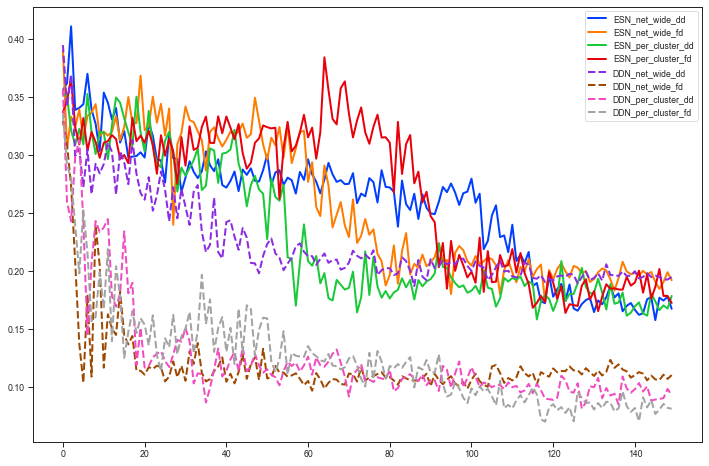

In [17]:
sns.set_theme(style="ticks", font_scale=1, palette='bright', context='paper')

plt.figure(figsize=(12,8))
gen_start = 0
gen_end = gen_max
for factor_1 in val_scores:
    for factor_2 in val_scores[factor_1]:
        for factor_3 in val_scores[factor_1][factor_2]:
            line = '-'
            if factor_1 == 'DDN':
                line = '--'
            plt.plot(val_scores[factor_1][factor_2][factor_3][gen_start:gen_end], label=factor_1 + '_' + factor_2 + '_' + factor_3, linestyle=line, linewidth=2)

# plt.ylim(0, 1)         
plt.legend()

NameError: name 'MG_imports' is not defined

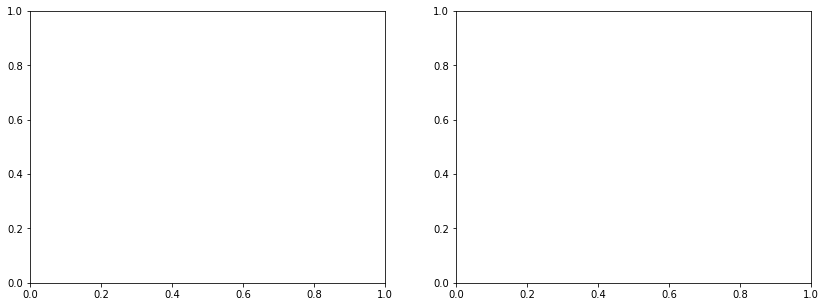

In [6]:
fig, ax= plt.subplots(1, 2, figsize=(14,5))
for net_type in MG_imports:
    for sp, task_type in enumerate(MG_imports[net_type]):
        ax[sp].set_title(task_type)
        # ax[sp].set_ylim(0, 510)

        for het_type in MG_imports[net_type][task_type]:
            df_to_plot = MG_imports[net_type][task_type][het_type]['evo_df']
            plot_name = net_type + "_" + het_type
            sns.lineplot(df_to_plot, x='Generation', y='Prediction Horizon', ax=ax[sp], linewidth=2, linestyle="-",label=plot_name, errorbar='sd')

ax[0].legend(fontsize=10)
ax[1].legend(fontsize=10)


## Basic runs
Just standard ESN and DDN in fixed tau condition, as in chapter 3

In [7]:
def get_best_candidate(dict, gen_max, multitask=False):
    best_gen_scores = get_validation_throughout_evolution(dict, gen_max, multitask=multitask)   
    best_candidates = get_validation_throughout_evolution(dict, gen_max, populations=True, multitask=multitask)
    best_gen_ind = np.argmin(best_gen_scores)
    best_candidate_ind = np.argmin(best_candidates[best_gen_ind])
    return best_gen_ind, best_candidate_ind
    
def sample_best_net(dict, n, gen_max, multitask=False):
    gen, ind = get_best_candidate(dict, gen_max, multitask=multitask)
    print(gen, ind)
    start_net = dict['example net']
    best_parameter_set = dict['parameters'][gen, ind, :]
    best_nets = []
    for i in range(n):
        best_net = start_net.get_new_network_from_serialized(best_parameter_set)
        best_nets.append(best_net)
    return best_nets


# Test
Import and plot test performances

In [8]:
best_lags = []
lags_are_different = 0
total_inds = 0 
for factor_2 in results_dicts['DDN']:
    for factor_3 in results_dicts['DDN'][factor_2]:
        for gen in range(0, gen_max):
            for ind in range(0, 20):
                total_inds += 1
                val_score = results_dicts['DDN'][factor_2][factor_3]['validation performance'][gen, ind]
                best_lag_cand = np.argmin(val_score, axis=-1)
                print(best_lag_cand)
                if len(np.unique(best_lag_cand[:])) > 1:
                    print(best_lag_cand[:])
        # gen, ind = get_best_candidate(results_dicts['ddn'][factor_2][factor_3], gen_max, multitask=multitask)
        # val_score = results_dicts['ddn'][factor_2][factor_3]['validation performance'][gen, ind]
        # print(gen, ind)
        # plt.plot(val_score[1, 1, :])


[7 8 7 7 7]
[7 8 7 7 7]
[5 7 5 5 9]
[5 7 5 5 9]
[ 6  6  8  6 14]
[ 6  6  8  6 14]
[7 9 7 7 8]
[7 9 7 7 8]
[8 8 7 5 6]
[8 8 7 5 6]
[8 6 7 0 0]
[8 6 7 0 0]
[6 6 6 5 5]
[6 6 6 5 5]
[5 4 5 7 7]
[5 4 5 7 7]
[0 6 0 6 5]
[0 6 0 6 5]
[ 7 12  6  5  6]
[ 7 12  6  5  6]
[1 2 1 1 4]
[1 2 1 1 4]
[ 5 11  6  6  5]
[ 5 11  6  6  5]
[7 7 7 7 7]
[3 3 3 5 0]
[3 3 3 5 0]
[ 6  6  1 14  3]
[ 6  6  1 14  3]
[8 8 6 8 7]
[8 8 6 8 7]
[0 0 7 1 8]
[0 0 7 1 8]
[ 2 12 12  1  8]
[ 2 12 12  1  8]
[2 2 2 2 2]
[5 5 5 5 5]
[6 6 8 6 8]
[6 6 8 6 8]
[6 6 7 6 6]
[6 6 7 6 6]
[2 7 7 2 6]
[2 7 7 2 6]
[3 4 4 4 4]
[3 4 4 4 4]
[5 3 5 4 5]
[5 3 5 4 5]
[4 0 4 4 0]
[4 0 4 4 0]
[7 8 7 8 8]
[7 8 7 8 8]
[3 1 2 2 2]
[3 1 2 2 2]
[4 2 6 5 7]
[4 2 6 5 7]
[4 4 4 5 4]
[4 4 4 5 4]
[0 0 6 7 0]
[0 0 6 7 0]
[6 7 8 5 7]
[6 7 8 5 7]
[5 4 4 4 6]
[5 4 4 4 6]
[8 4 2 8 5]
[8 4 2 8 5]
[6 6 7 6 6]
[6 6 7 6 6]
[ 1  0  7  8 13]
[ 1  0  7  8 13]
[0 0 7 0 0]
[0 0 7 0 0]
[0 8 8 9 8]
[0 8 8 9 8]
[1 4 4 0 0]
[1 4 4 0 0]
[1 6 3 3 6]
[1 6 3 3 6]
[6 6 9 5 9]
[6 6

In [10]:
multitask = False
final_nets = {}
for factor_1 in results_dicts:
    final_nets[factor_1] = {}
    for factor_2 in results_dicts[factor_1]:
        final_nets[factor_1][factor_2] = {}
        for factor_3 in results_dicts[factor_1][factor_2]:
            best_nets = sample_best_net(results_dicts[factor_1][factor_2][factor_3], 15, gen_max, multitask=multitask)
            final_nets[factor_1][factor_2][factor_3] = best_nets

145 15
118 7
116 10
123 14
86 5
61 24
127 5
118 0


In [11]:
from utils import eval_candidate_lag_gridsearch_NARMA, createNARMA30, createNARMA10, eval_candidate_lag_gridsearch_NARMA_multitask, inputs2NARMA

if multitask:
    inputs_train, labels_train_10 = createNARMA10(8000)
    inputs_val, labels_val_10 = createNARMA10(4000)

    labels_train_30 = inputs2NARMA(inputs_train, system_order=30, coef=[.2, .04, 1.5, .001])
    labels_val_30 = inputs2NARMA(inputs_val, system_order=30, coef=[.2, .04, 1.5, .001])

else:
    data_train = np.array(createNARMA30(8000)).reshape((2, 8000))
    data_test = np.array(createNARMA30(4000)).reshape((2, 4000))

alphas = [10e-7, 10e-5, 10e-3]

test_results = {
    'Test NRMSE' : [],
    'Network type': [],
    'Distribution heterogeneity': [],
    'Cluster heterogeneity': []
}

def write(dict, score, net_type, f1, f2):
    dict['Test NRMSE'].append(score)
    dict['Network type'].append(net_type)
    dict['Distribution heterogeneity'].append(f1)
    dict['Cluster heterogeneity'].append(f2)
    
for factor_1 in final_nets:
    # print(factor_1)
    for factor_2 in final_nets[factor_1]:
        # print(factor_2)
        for factor_3 in final_nets[factor_1][factor_2]:
            print(factor_1, factor_2, factor_3)
            for net in final_nets[factor_1][factor_2][factor_3]:
                if not multitask:
                    val_scores_lags, _ = eval_candidate_lag_gridsearch_NARMA(net, data_train, data_test,alphas=alphas)
                    best_lag_score = np.min(val_scores_lags)
                    write(test_results, best_lag_score, factor_1, factor_2, factor_3)
                else:
                    _, val_score_per_task, _ = eval_candidate_lag_gridsearch_NARMA_multitask(net,inputs_train, inputs_val, [labels_train_10, labels_train_30], [labels_val_10, labels_val_30], alphas=alphas)
                    val_score_per_task = np.array(val_score_per_task)
                    best_lag_score = np.min(val_score_per_task, axis=-1)
                    task_average_score = np.mean(best_lag_score, axis=-1)
                    write(test_results, task_average_score, factor_1, factor_2, factor_3)
                

ESN net_wide dd
ESN net_wide fd
ESN per_cluster dd
ESN per_cluster fd
DDN net_wide dd
DDN net_wide fd
DDN per_cluster dd
DDN per_cluster fd


In [37]:
test_results_df = pd.DataFrame(test_results)

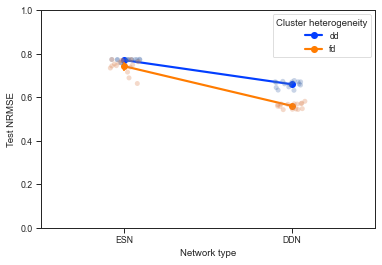

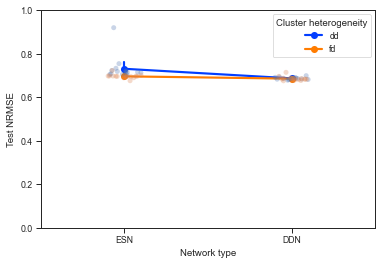

In [38]:
sns.pointplot(test_results_df[test_results_df['Distribution heterogeneity']=='net_wide'], x='Network type', y='Test NRMSE', hue='Cluster heterogeneity',)
sns.stripplot(test_results_df[test_results_df['Distribution heterogeneity']=='net_wide'], x='Network type', hue='Cluster heterogeneity', y='Test NRMSE', legend=False, alpha=0.3, palette='deep')
plt.ylim(0, 1)
# plt.savefig('G:/My Drive/Data For Publication/paper3/figs_NARMA/heterogeneity_analysis_narma_net_wide.pdf', dpi=300, bbox_inches='tight')
plt.show()

sns.pointplot(test_results_df[test_results_df['Distribution heterogeneity']=='per_cluster'], x='Network type', y='Test NRMSE', hue='Cluster heterogeneity',)
sns.stripplot(test_results_df[test_results_df['Distribution heterogeneity']=='per_cluster'], x='Network type', hue='Cluster heterogeneity', y='Test NRMSE', legend=False, alpha=0.3, palette='deep')
plt.ylim(0, 1)
# plt.savefig('G:/My Drive/Data For Publication/paper3/figs_NARMA/heterogeneity_analysis_narma_per_cluster.pdf', dpi=300, bbox_inches='tight')
plt.show()

## Single Tau task

In [16]:
test_dict_pd = {
    'Network Type': [],
    'Decay Heterogeneity': [],
    'Test Performance': []
}
for net_type in MG_imports:
    for het_type in MG_imports[net_type]['fixed tau']:
        test_dict = MG_imports[net_type]['fixed tau'][het_type]['test_dict']
        test_data = np.array(test_dict[17])
        print(net_type, het_type)
        print(test_data)
        test_data = list(np.average(test_data, axis=-1))
        # print(test_data)
        n_samples = len(test_data)
        test_dict_pd['Test Performance'] += test_data
        test_dict_pd['Network Type'] += [net_type] * n_samples
        test_dict_pd['Decay Heterogeneity'] += [het_type] * n_samples

test_pd = pd.DataFrame.from_dict(test_dict_pd)
# sns.pointplot(test_df, x=x_label, y=y_label, hue=hue_label, errorbar='se', palette='deep', markers='o', markersize=5)

sns.pointplot(data=test_pd, x='Network Type', hue='Decay Heterogeneity', errorbar='se', y='Test Performance', palette='deep', markers='o')

sns.stripplot(data=test_pd, x='Network Type', hue='Decay Heterogeneity', y='Test Performance', legend=False, alpha=0.3, palette='deep')
plt.title('Test Fixed Tau')

NameError: name 'MG_imports' is not defined

Text(0.5, 1.0, 'Test Fixed Tau')

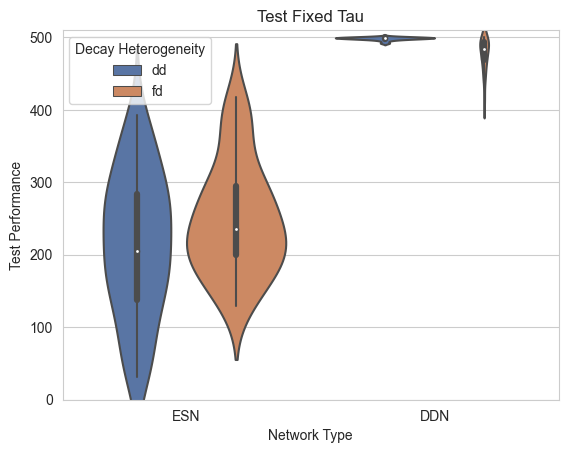

In [9]:
sns.violinplot(data=test_pd, x='Network Type', hue='Decay Heterogeneity', y='Test Performance', palette='deep')
plt.ylim(0, 510)
plt.title('Test Fixed Tau')

## Multi Tau task
Here we look at both averaged over tau and separate per tau

Text(0.5, 1.0, 'Test Variable Tau')

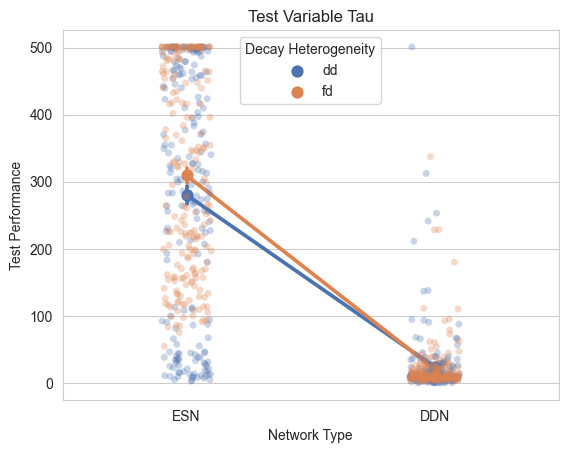

In [10]:
test_dict_pd_vt = {
    'Network Type': [],
    'Decay Heterogeneity': [],
    'Tau': [],
    'Test Performance': []
}
for net_type in MG_imports:
    for het_type in MG_imports[net_type]['variable tau']:
        test_dict = MG_imports[net_type]['variable tau'][het_type]['test_dict']
        for tau in test_dict:
            test_data = np.array(test_dict[tau])
            test_data = list(np.average(test_data, axis=-1))
            n_samples = len(test_data)
            test_dict_pd_vt['Test Performance'] += test_data
            test_dict_pd_vt['Network Type'] += [net_type] * n_samples
            test_dict_pd_vt['Decay Heterogeneity'] += [het_type] * n_samples
            test_dict_pd_vt['Tau'] += [tau] * n_samples

test_pd_vt = pd.DataFrame.from_dict(test_dict_pd_vt)
# sns.pointplot(test_df, x=x_label, y=y_label, hue=hue_label, errorbar='se', palette='deep', markers='o', markersize=5)

sns.pointplot(data=test_pd_vt, x='Network Type', hue='Decay Heterogeneity', errorbar='se', y='Test Performance', palette='deep', markers='o')

sns.stripplot(data=test_pd_vt, x='Network Type', hue='Decay Heterogeneity', y='Test Performance', legend=False, alpha=0.3, palette='deep')
plt.title('Test Variable Tau')

Text(0.5, 1.0, 'Test Variable Tau')

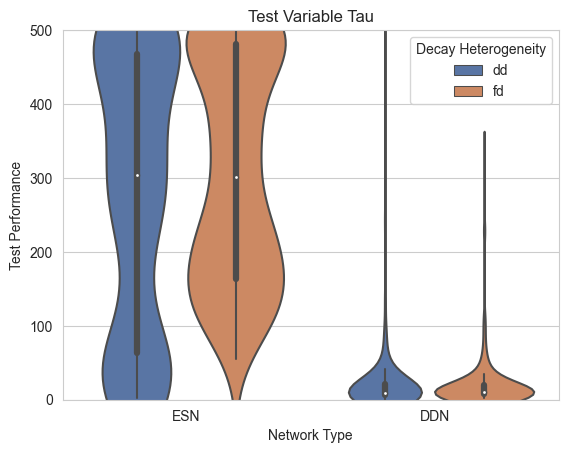

In [11]:
sns.violinplot(data=test_pd_vt, x='Network Type', hue='Decay Heterogeneity', y='Test Performance', palette='deep')
plt.ylim(0, 500)
plt.title('Test Variable Tau')

Text(0.5, 1.0, 'Distributed Decay')

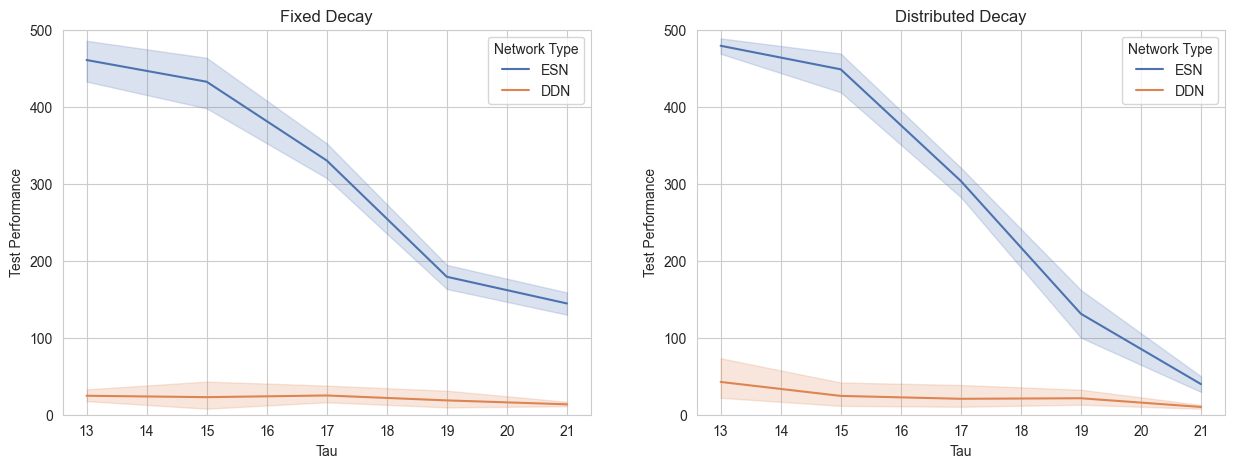

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.lineplot(data=test_pd_vt[test_pd_vt['Decay Heterogeneity'] == 'fd'], x='Tau', hue='Network Type', y='Test Performance', palette='deep', ax=ax[0])
ax[0].set_ylim(0, 500)
ax[0].set_title('Fixed Decay')

sns.lineplot(data=test_pd_vt[test_pd_vt['Decay Heterogeneity'] == 'dd'], x='Tau', hue='Network Type', y='Test Performance', palette='deep', ax=ax[1])
ax[1].set_ylim(0, 500)
ax[1].set_title('Distributed Decay')

